In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
plt.style.use("style.mplstyle")
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
dataset = baseClasses.Data()

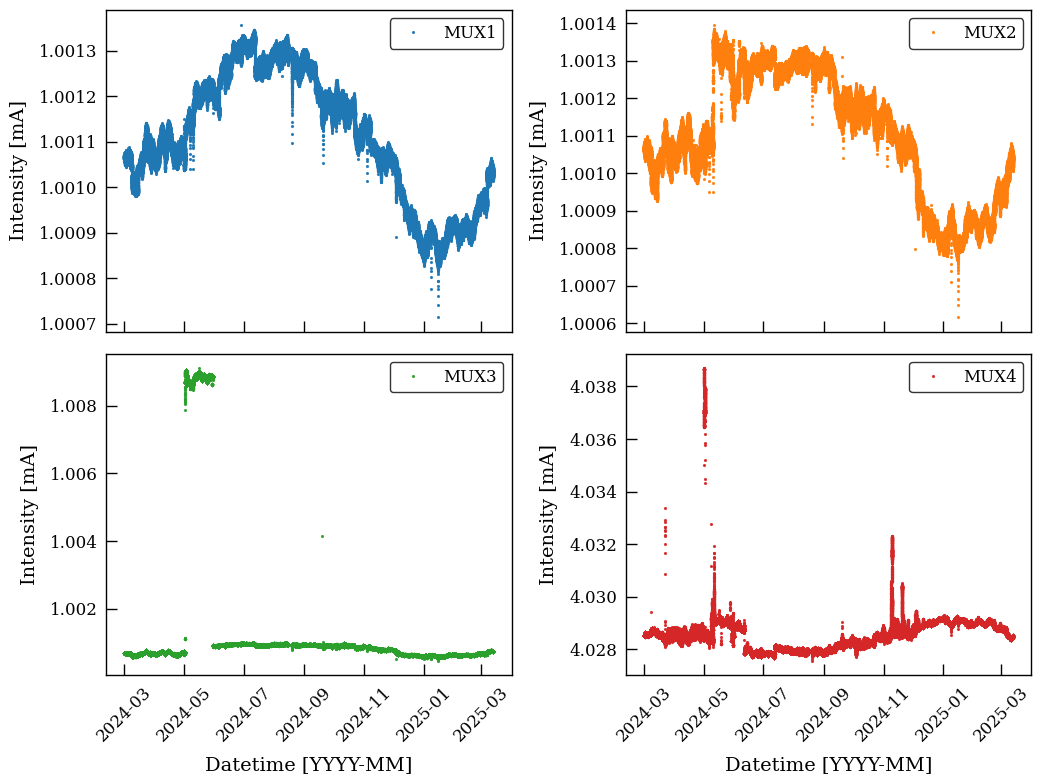

In [ ]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

mux1.data = mux1.data.loc[(mux1.data>1)&(mux1.data<1.0014)]
mux2.data = mux2.data.loc[(mux2.data>1)&(mux2.data<1.0014)]
mux3.data = mux3.data.loc[(mux3.data>1)&(mux3.data<1.1)]
mux4.data = mux4.data.loc[(mux4.data>4)&(mux4.data<4.05)]
ambient = sensorClasses.Sensor(dataset=dataset, id=1037)
fig, ax = plt.subplots(2,2,figsize=(10.6, 8), sharex=True, sharey=False)
ax = ax.flatten()
ax[0].plot(mux1.data.index.values, mux1.data.values, ".", label="MUX1", color="tab:blue", alpha=0.9)
ax[1].plot(mux2.data.index.values, mux2.data.values, ".", label="MUX2", color="tab:orange", alpha=0.9)
ax[2].plot(mux3.data.index.values, mux3.data.values, ".", label="MUX3", color="tab:green", alpha=0.9)
ax[3].plot(mux4.data.index.values, mux4.data.values, ".", label="MUX4", color="tab:red", alpha=0.9)
ax[2].tick_params(axis='x', rotation=45)
ax[3].tick_params(axis='x', rotation=45)
ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()
ax[0].set_ylabel("Intensity [mA]")
ax[1].set_ylabel("Intensity [mA]")
ax[2].set_ylabel("Intensity [mA]")
ax[3].set_ylabel("Intensity [mA]")
ax[2].set_xlabel("Datetime [YYYY-MM]")
ax[3].set_xlabel("Datetime [YYYY-MM]")
fig.tight_layout()

In [ ]:
mux2_corr = mux2.data.copy()
mux2_corr.loc[(mux2_corr.index >= pd.Timestamp("2024-05-03 21:20:00"))&(mux2_corr.index < pd.Timestamp("2024-05-04 12:45:00"))] -= 0.00004
mux2_corr.loc[mux2_corr.index >= pd.Timestamp("2024-05-10 15:00:00")] -= 0.00012
mux2_corr.loc[mux2_corr.index >= pd.Timestamp("2024-05-30 11:00:00")] += 0.00003
mux2_corr.loc[(mux2_corr.index >= pd.Timestamp("2024-05-31 16:35:00"))] -= 0.00005
mux2_corr.loc[mux2_corr.index >= pd.Timestamp("2024-06-11 17:00:00")] += 0.00007

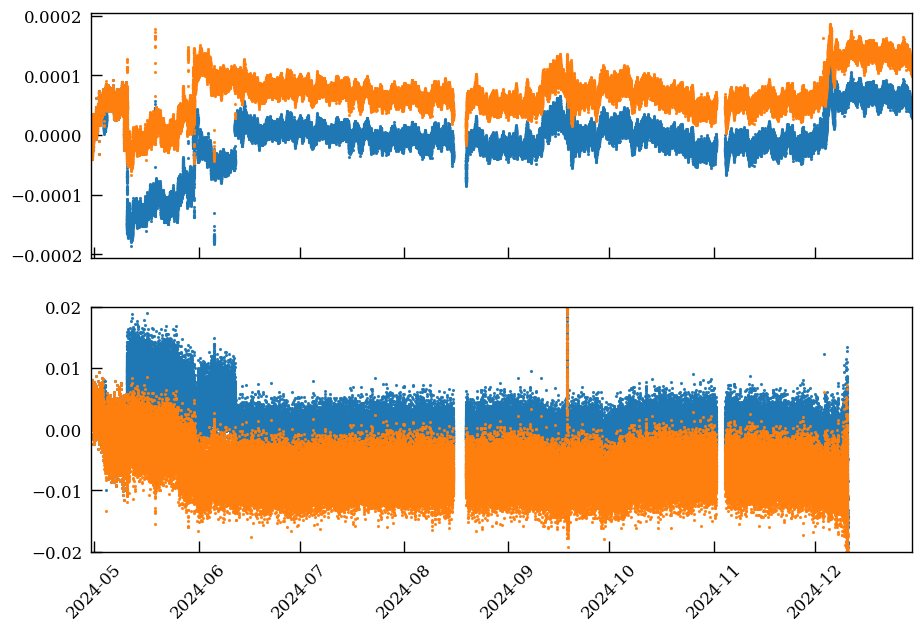

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10.6, 7), sharex=True)
ax[0].plot((mux1.data-mux2.data).index.values, (mux1.data-mux2.data).values, ".", label="MUX1", color="tab:blue", alpha=0.9)
ax[0].plot((mux1.data-mux2.data).index.values, (mux1.data-mux2_corr).values, ".", label="MUX1", color="tab:orange", alpha=0.9)
ax[0].set_xlim(pd.Timestamp("2024-4-30 00:00:00"), pd.Timestamp("2024-12-30 00:00:00"))
ax[1].plot((dataset.data["TE0024"]/mux1.data - dataset.data["TE0025"]/mux2.data).index.values,
           (dataset.data["TE0024"]/mux1.data - dataset.data["TE0025"]/mux2.data).values,
           ".", label="Ambient", color="tab:blue", alpha=0.9)
ax[1].plot((dataset.data["TE0024"]/mux1.data - dataset.data["TE0025"]/mux2_corr).index.values,
           (dataset.data["TE0024"]/mux1.data - dataset.data["TE0025"]/mux2_corr).values,
           ".", label="Ambient", color="tab:orange", alpha=0.9)
ax[1].set_ylim(-0.02,0.02)
ax[1].tick_params(axis='x', rotation=45)
# ax.plot((mux1.data-mux3.data).index.values, (mux1.data-mux3.data).values, ".", label="MUX1", color="tab:blue", alpha=0.9)

(-0.02, 0.02)

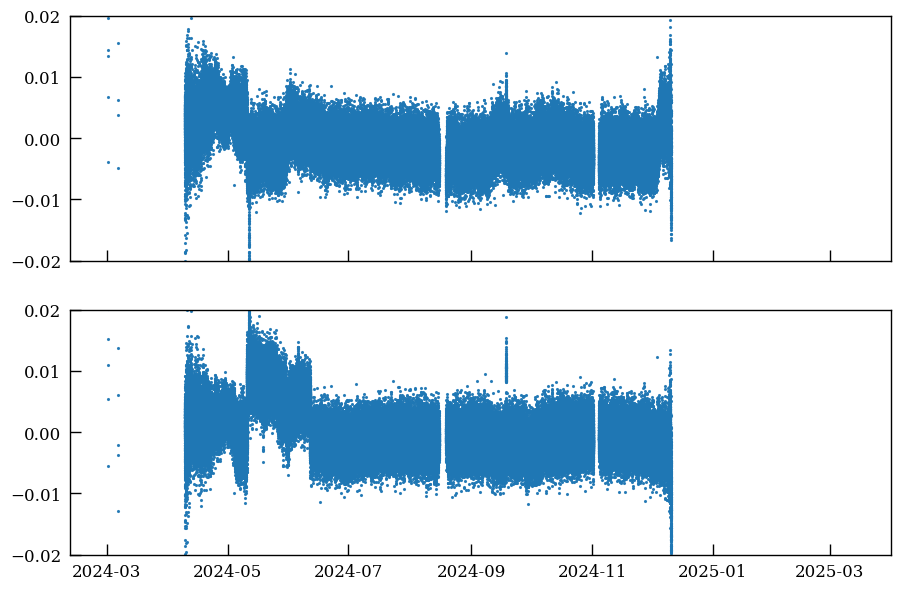

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10.6, 7), sharex=True)
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39644)
sensor2 = sensorClasses.Sensor(dataset=dataset, id=39630)
sensor1.muxCorrection()
sensor2.muxCorrection()
ax[0].plot((sensor1.data-sensor2.data).index.values, (sensor1.data - sensor2.data).values, ".", label="Sensor 1", color="tab:blue", alpha=0.9)
ax[0].set_ylim(-0.02, 0.02)
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39644)
sensor2 = sensorClasses.Sensor(dataset=dataset, id=39630)
sensor1.muxCorrection(manual_correction=True)
sensor2.muxCorrection(manual_correction=True)
ax[1].plot((sensor1.data-sensor2.data).index.values, (sensor1.data - sensor2.data).values, ".", label="Sensor 1", color="tab:blue", alpha=0.9)
ax[1].set_ylim(-0.02, 0.02)

In [377]:
mux3_corr = mux3.data.copy()
mux3_corr.loc[mux3_corr.index >= pd.Timestamp("2024-05-02 9:00:00")] -= 0.00495
mux3_corr.loc[mux3_corr.index >= pd.Timestamp("2024-05-30 10:00:00")] += 0.007835
mux3_corr.loc[mux3_corr.index >= pd.Timestamp("2024-10-11 13:00:00")] -= 0.00001
mux3_corr.loc[mux3_corr.index >= pd.Timestamp("2024-10-11 16:00:00")] += 0.00042
# mux2_corr.loc[(mux2_corr.index >= pd.Timestamp("2024-05-03 21:20:00"))&(mux2_corr.index < pd.Timestamp("2024-05-04 12:45:00"))] -= 0.00004
# mux2_corr.loc[mux2_corr.index >= pd.Timestamp("2024-05-10 15:00:00")] -= 0.00012
# mux2_corr.loc[mux2_corr.index >= pd.Timestamp("2024-05-30 11:00:00")] += 0.00003
# mux2_corr.loc[(mux2_corr.index >= pd.Timestamp("2024-05-31 16:35:00"))] -= 0.00005
# mux2_corr.loc[mux2_corr.index >= pd.Timestamp("2024-06-11 17:00:00")] += 0.00007

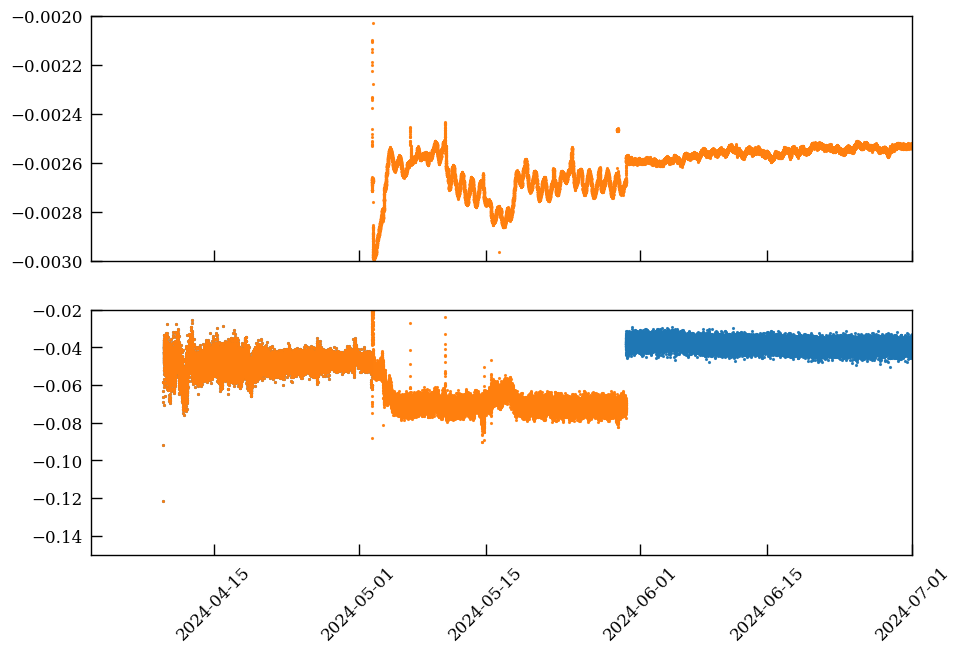

In [379]:
fig, ax = plt.subplots(2, 1, figsize=(10.6, 7), sharex=True)
ax[0].plot((mux1.data-mux3.data).index.values, (mux1.data-mux3.data).values, ".", label="MUX1", color="tab:blue", alpha=0.9)
ax[0].plot((mux1.data-mux3.data).index.values, (mux1.data-mux3_corr).values, ".", label="MUX1", color="tab:orange", alpha=0.9)
ax[0].set_ylim(-0.003, -0.002)
ax[0].set_xlim(pd.Timestamp("2024-4-1 10:00:00"), pd.Timestamp("2024-7-1 00:00:00"))
ax[1].plot((dataset.data["TE0024"]/mux1.data - dataset.data["TE0050"]/mux3.data).index.values,
           (dataset.data["TE0024"]/mux1.data - dataset.data["TE0050"]/mux3.data).values,
           ".", label="Ambient", color="tab:blue", alpha=0.9)
ax[1].plot((dataset.data["TE0024"]/mux1.data - dataset.data["TE0050"]/mux3_corr).index.values,
           (dataset.data["TE0024"]/mux1.data - dataset.data["TE0050"]/mux3_corr).values,
           ".", label="Ambient", color="tab:orange", alpha=0.9)
ax[1].set_ylim(-0.1,-0.02)
ax[1].set_ylim(-0.15,-0.02)
ax[1].tick_params(axis='x', rotation=45)
# ax.plot((mux1.data-mux3.data).index.values, (mux1.data-mux3.data).values, ".", label="MUX1", color="tab:blue", alpha=0.9)